In [2]:
fig_num = 7 # change this to the figure number
analysis_name = "readysetgo" # change this to the subfolder it should save to

from c3po.analysis.analysis import figure_directory
from pathlib import Path
fig_dir = Path(figure_directory) / f"Fig{fig_num}" /analysis_name
fig_dir.mkdir(parents=True, exist_ok=True)
fig_dir

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

In [1]:
import pandas as pd
from pathlib import Path
file_path = "/home/sambray/Documents/c3po/tutorial/c3po_dandi_candidate_datasets_v2.csv"
dataset_df = pd.read_csv(file_path)

dandiset_id = 130

dataset_df = dataset_df[dataset_df['dandiset_id'] == dandiset_id]

dandiset_id = f"{dandiset_id:06d}"
dandi_path = dataset_df['dandi_path'].values[0]
model_dir = Path(f"/stelmo/sam/c3po_dandi_training_v2/{dandiset_id}")

In [3]:
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # Disable GPU usage for this example

from pathlib import Path
from dandi.dandiapi import DandiAPIClient
from dandi.consts import known_instances
import fsspec
from fsspec.implementations.cached import CachingFileSystem
import h5py
import pynwb

def get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi"):
    tmp_dir = "dandi_cache"  # Local folder for cache
    Path(tmp_dir).mkdir(exist_ok=True)  # Create the cache folder if it doesn't exist

    # get the s3 url from Dandi
    with DandiAPIClient(
        dandi_instance=known_instances[dandi_instance],
    ) as client:
        asset = client.get_dandiset(dandiset_id).get_asset_by_path(dandi_path)
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

    # stream the file from s3
    # first, create a virtual filesystem based on the http protocol
    fs = fsspec.filesystem("http")

    # create a cache to save downloaded data to disk (optional)
    fsspec_file = CachingFileSystem(
        fs=fs,
        cache_storage=tmp_dir,  # Local folder for cache
    )

    # Open and return the file
    fs_file = fsspec_file.open(s3_url, "rb")
    io = pynwb.NWBHDF5IO(file=h5py.File(fs_file))
    nwbfile = io.read()
    return io, nwbfile

In [4]:
nwbfile = get_dandi_file(dandiset_id, dandi_path, dandi_instance="dandi")[1]

In [5]:
from c3po.analysis.analysis import C3poAnalysis
import numpy as np
analysis = C3poAnalysis(model_dir=model_dir)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

In [11]:
nwbfile

root pynwb.file.NWBFile at 0x140384474455520
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">
  lab: Jazayeri
  related_publications: ['http://dx.doi.org/10.1016/j.neuron.2019.06.012']
  session_description: Data from monkey Haydn performing ready-set-go time interval reproduction task. This file contains continuous segments of the full session on 2016-12-11 that can be used for training models for the Neural Latents Benchmark.
  session_id: 20161211
  session_start_time: 2016-12-11 00:00:00-05:00
  subject: subject pynwb.file.Subject at 0x140384474450864
Fields:
  age: P4Y
  sex: M
  species: Macaca mulatta
  subject_id: Haydn

  timestamps_reference_time: 2016-12-11 00:00:00-05:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>
  units: units <class 'pynwb.misc.Units'>

In [7]:
obj_id = dataset_df['event_object_id'].values[0]
event_df = nwbfile.objects[obj_id].to_dataframe()
event_df.columns

Index(['start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time',
       'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time',
       'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur',
       'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split'],
      dtype='object')

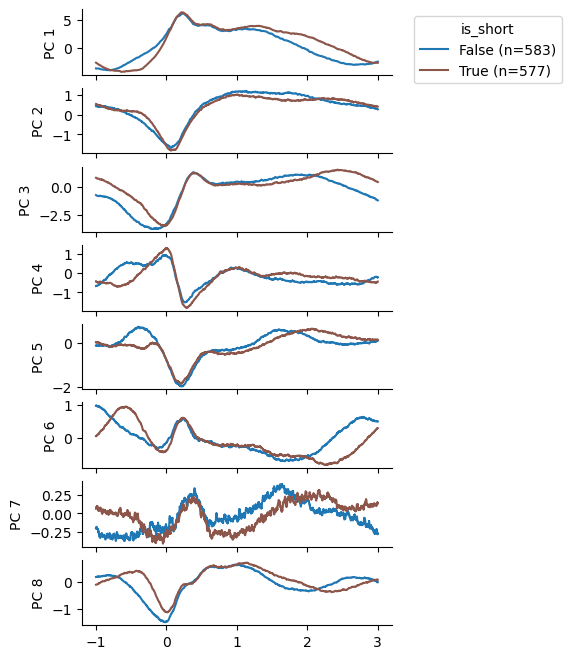

In [42]:
mark = "go_time"
feature = "is_short"
window = (-1,3)

fig, ax = plt.subplots(nrows = 8, sharex=True, figsize=(4,8))
feature_val_list = event_df[feature].unique()
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for i_feat, feature_val in enumerate(feature_val_list):
    df = event_df[event_df[feature] == feature_val]
    result = analysis.alligned_response(df[mark].values, window, pca=True)
    mid = np.mean(result, axis=0)
    # low = np.percentile(result, 25, axis=0)
    # high = np.percentile(result, 75, axis=0)
    if isinstance(feature_val, str) or isinstance(feature_val, np.bool_):
        color = i_feat / len(feature_val_list)
        color = plt.cm.tab10(color)
    else:
        color = (feature_val - np.min(feature_val_list)) / (np.max(feature_val_list) - np.min(feature_val_list))
        color = plt.cm.viridis(color)
    t_plot = np.linspace(window[0], window[1], mid.shape[0])

    for i, a in enumerate(ax):
        # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
        label = f"{feature_val} (n={len(df)})"
        a.plot(t_plot, mid[:,i], color=color, label=label)
        a.set_ylabel(f"PC {i+1}")
        a.spines[['top', 'right']].set_visible(False)
ax[0].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

Text(0.5, 0, 'Time from set_time (s)')

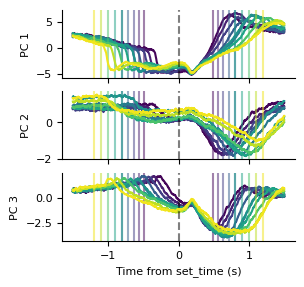

In [ ]:
mark = "set_time"
feature = "target_time_dur"
window = (-1.5,1.5)

fig, ax = plt.subplots(nrows = 3, sharex=True, figsize=(3,3))

# feature_vals = event_df[feature].values

feature_vals = event_df['set_time'].values - event_df['ready_time'].values
feature_val_list = np.unique(feature_vals)
# feature_bins = np.linspace(np.min(feature_val_list), np.max(feature_val_list), 5)
feature_bins = np.nanpercentile(feature_val_list, np.linspace(0,100,11))
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for i_feat in range(feature_bins.size - 1):
    ind = (feature_vals >= feature_bins[i_feat]) & (feature_vals < feature_bins[i_feat + 1])
    df = event_df[ind]
    central_val = np.median(feature_vals[ind])
    result = analysis.alligned_response(df[mark].values, window, pca=True)
    mid = np.mean(result, axis=0)
    # low = np.percentile(result, 25, axis=0)
    # high = np.percentile(result, 75, axis=0)
    feature_val = np.mean(feature_bins[i_feat:i_feat + 2])  # Use the mean of the bin for color mapping

    color = (feature_val - np.min(feature_bins)) / (np.max(feature_bins) - np.min(feature_bins))
    color = plt.cm.viridis(color)
    t_plot = np.linspace(window[0], window[1], mid.shape[0])

    for i, a in enumerate(ax):
        # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
        label = f"{feature_val} (n={len(df)})"
        a.plot(t_plot, mid[:,i], color=color, label=label)
        a.set_ylabel(f"PC {i+1}")
        a.spines[['top', 'right']].set_visible(False)

        a.axvline(central_val, color=color, linestyle='-', alpha=0.5,)
        a.axvline(-central_val, color=color, linestyle='-', alpha=0.5,)

for a in ax:
    a.axvline(0, color='k', linestyle='--', alpha=0.5)
# ax[0].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

ax[-1].set_xlabel(f"Time from {mark} (s)")

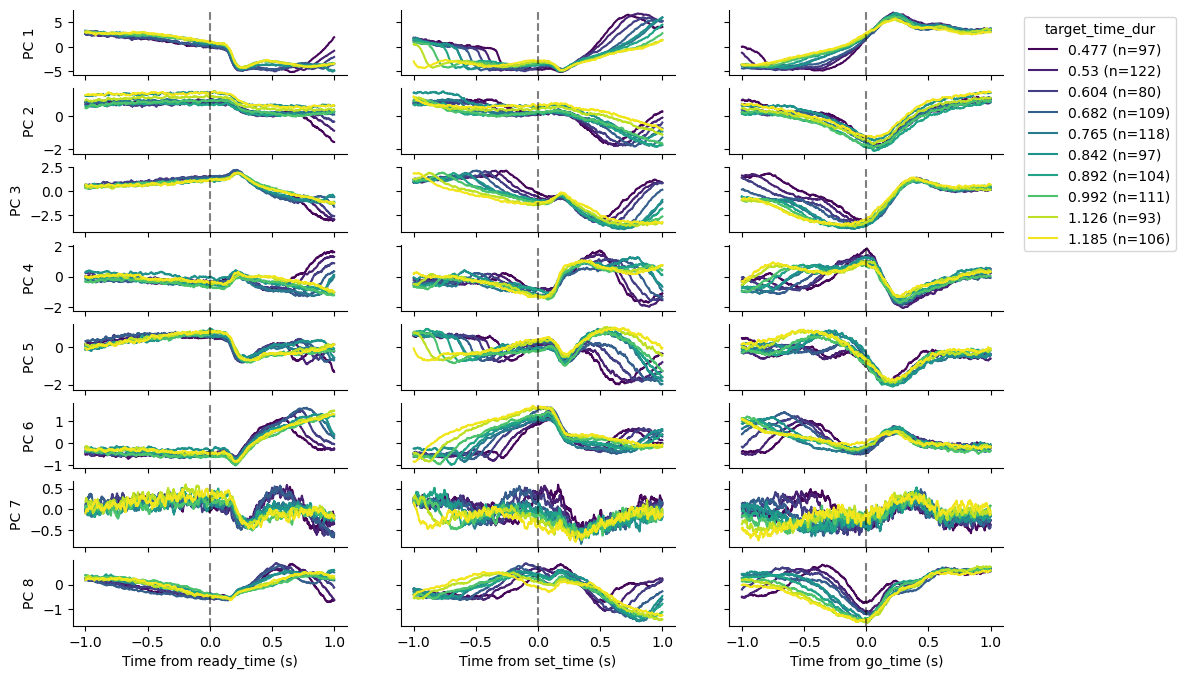

In [ ]:
mark_list = ["ready_time", "set_time", "go_time"]
feature = "target_time_dur"
window_list = [(-1,1), (-1.5,1.5), (-1,3)]

fig, ax_list = plt.subplots(nrows = 8, ncols=len(mark_list), sharey="row", sharex=True,
                            figsize=(len(mark_list)*4,8))


# feature_vals = event_df[feature].values

feature_vals = event_df['set_time'].values - event_df['ready_time'].values
feature_val_list = np.unique(feature_vals)
# feature_bins = np.linspace(np.min(feature_val_list), np.max(feature_val_list), 5)
feature_bins = np.nanpercentile(feature_val_list, np.linspace(0,100,11))
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for mark_idx, mark in enumerate(mark_list):
    ax = ax_list[:, mark_idx]

    for i_feat in range(feature_bins.size - 1):
        ind = (feature_vals >= feature_bins[i_feat]) & (feature_vals < feature_bins[i_feat + 1])
        df = event_df[ind]
        result = analysis.alligned_response(df[mark].values, window, pca=True)
        mid = np.mean(result, axis=0)
        # low = np.percentile(result, 25, axis=0)
        # high = np.percentile(result, 75, axis=0)
        feature_val = np.mean(feature_bins[i_feat:i_feat + 2])  # Use the mean of the bin for color mapping
        feature_val = np.round(feature_val, 3)
        color = (feature_val - np.min(feature_bins)) / (np.max(feature_bins) - np.min(feature_bins))
        color = plt.cm.viridis(color)
        t_plot = np.linspace(window[0], window[1], mid.shape[0])

        for i, a in enumerate(ax):
            # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
            label = f"{feature_val} (n={len(df)})"
            a.plot(t_plot, mid[:,i], color=color, label=label)
            if mark_idx == 0:
                a.set_ylabel(f"PC {i+1}")
            a.spines[['top', 'right']].set_visible(False)
    for a in ax:
        a.axvline(0, color='k', linestyle='--', alpha=0.5)


    ax[-1].set_xlabel(f"Time from {mark} (s)")
ax_list[0,-1].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

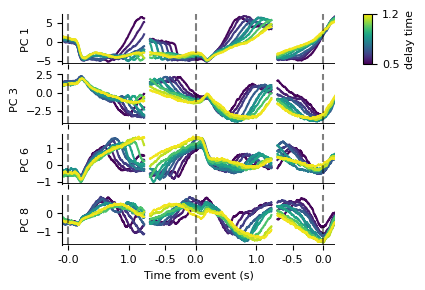

In [ ]:
mark_list = ["ready_time", "set_time", "go_time"]
window_list = [(-.1,1.25), (-.75,1.25), (-.75,.2)]
offset_list = [-2.1, 0, 2.1]

pc_to_plot = [0, 2, 5,7]
fig, ax_list_all = plt.subplots(nrows = len(pc_to_plot), ncols=2,
                                width_ratios = [30,1],
                                sharey=False, sharex="col",
                            figsize=(4,3))
ax_list = ax_list_all[:,0]


# feature_vals = event_df[feature].values

feature = "delay time"
feature_vals = event_df['set_time'].values - event_df['ready_time'].values
feature_val_list = np.unique(feature_vals)
# feature_bins = np.linspace(np.min(feature_val_list), np.max(feature_val_list), 5)
feature_bins = np.nanpercentile(feature_val_list, np.linspace(0,100,11))
# feature_val_list = [val for val in feature_val_list if "presentation" in val]

for mark_idx, (mark, window, offset) in enumerate(zip(mark_list, window_list, offset_list)):
    ax = ax_list[:]

    for i_feat in range(feature_bins.size - 1):
        ind = (feature_vals >= feature_bins[i_feat]) & (feature_vals < feature_bins[i_feat + 1])
        df = event_df[ind]
        result = analysis.alligned_response(df[mark].values, window, pca=True)
        mid = np.mean(result, axis=0)
        # low = np.percentile(result, 25, axis=0)
        # high = np.percentile(result, 75, axis=0)
        feature_val = np.mean(feature_bins[i_feat:i_feat + 2])  # Use the mean of the bin for color mapping
        feature_val = np.round(feature_val, 3)
        color = (feature_val - np.min(feature_bins)) / (np.max(feature_bins) - np.min(feature_bins))
        color = plt.cm.viridis(color)
        t_plot = np.linspace(window[0], window[1], mid.shape[0]) + offset

        for i, a in enumerate(ax):
            # a.fill_between(t_plot, low[:,i], high[:,i], color=plt.cm.viridis(color), alpha=0.3)
            label = f"{feature_val} (n={len(df)})"
            pc = pc_to_plot[i]
            a.plot(t_plot, mid[:,pc], color=color, label=label)
            if mark_idx == 0:
                a.set_ylabel(f"PC {pc+1}")
            a.spines[['top', 'right']].set_visible(False)
    for a in ax:
        a.axvline(offset, color='k', linestyle='--', alpha=0.5)


    ax[-1].set_xlabel(f"Time from {mark} (s)")

ticks = []
labels = []
for mark, offset, window in zip(mark_list, offset_list, window_list):
    ticks_i = np.unique(np.trunc(2 * np.array(window)) /2)
    ticks_i = np.unique(np.concatenate([ticks_i, np.array([0])]))
    ticks.extend(ticks_i + offset)
    labels.extend([f"{tick:.1f}" for tick in ticks_i])
    for a in ax_list:
        ylim = a.get_ylim()
        a.spines["bottom"].set_visible(False)
        a.plot([offset+window[0], offset+window[1]], [ylim[0], ylim[0]], color='k', linewidth=2)
        a.set_ylim(ylim)
ax_list[-1].set_xticks(ticks, labels=labels)
ax_list[-1].set_xlim([offset_list[0]+window_list[0][0], offset_list[-1]+window_list[-1][1]])
ax_list[-1].set_xlabel(f"Time from event (s)")
# ax_list[0,].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')

cb = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), cax=ax_list_all[0,1], orientation='vertical',
                   label=feature)
cb.set_ticks([0, 1], labels=[f"{np.min(feature_bins):.1f}", f"{np.max(feature_bins):.1f}"])

for a in ax_list_all[1:,1]:
    a.axis('off')

fig.savefig(fig_dir/ "aligned_response.svg")

In [48]:
fig_dir

PosixPath('/home/sambray/Documents/c3po/Figures/Fig7/readysetgo')

(array([ 14.,   0.,  83.,   0.,   5.,   0.,   0.,   0.,   0.,   0.,   0.,
         15.,   0., 102.,   0.,   1.,   0.,   0.,   0.,   0.,  10.,   0.,
         77.,   0.,   1.,   3.,   0.,   0.,   0.,   0.,   0.,   8.,   0.,
          0.,  89.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,  29.,
          0., 177.,   0.,   4.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,  13.,   0.,   0.,  96.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,  12.,   0.,  92.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   5.,   5.,   0.,  85.,   0.,
          2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  13.,   0.,
         95.]),
 array([0.4665 , 0.47384, 0.48118, 0.48852, 0.49586, 0.5032 , 0.51054,
        0.51788, 0.52522, 0.53256, 0.5399 , 0.54724, 0.55458, 0.56192,
        0.56926, 0.5766 , 0.58394, 0.59128, 0.59862, 0.60596, 0.6133 ,
        0.62064, 0.62798, 0.63532, 0.64266, 0.65   , 0.65734, 0.66468,
        0.67202, 0.67936, 0.6867 ,

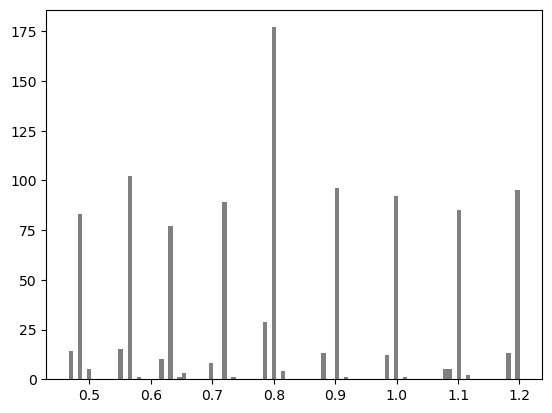

In [43]:
val = event_df['target_time_dur'].values

val = event_df['set_time'].values - event_df['ready_time'].values
plt.hist(val, bins = 100, color='grey')

In [22]:
dataset_df

,dandiset_id,dandi_path,publication_source,behavioral_or_experimental_feature_to_compare,number_of_units,brain_regions_of_recording,why_chosen,event_object_path,event_object_id,event_feature_name
19,689,sub-H19/sub-H19_ses-H19-2019-10-31-17-44-38-Di...,"Li et al., Nature (2022), https://doi.org/10.1...",Pavlovian discrimination trial type and valenc...,64,Amygdala (asset electrode location unspecified),Single-system aversive and appetitive learning...,/intervals/trials,b2a7b630-c4b5-4592-a6f9-720a0b3ec528,start_time


In [21]:
dataset_df.publication_source.values[0]

'Bayesian computation through cortical latent dynamics; https://doi.org/10.1016/j.neuron.2019.06.012'

In [62]:
import yaml
yaml_path = model_dir / "metrics.yaml"
metrics = yaml.safe_load(open(yaml_path, "r"))
metrics

{'dimensions': 16,
 'mua_rate': 298.39033644617325,
 'n_units': 54,
 'training_time': 725.4981343746185}

In [67]:
nwbfile.electrodes.to_dataframe().location.unique()

array(['DMFC'], dtype=object)